# Different Lattices Build by the UnitCell_Lattices Module

In [1]:
using Plots
include("../src/lattice.jl")
using .UnitCell_Lattices

# Square Lattice

In [2]:
# Creating a square lattice
A = [1.0 0.0 ;
     0.0 1.0] # Lattice vectors for a square lattice
B = [0.0 ;
     0.0 ]
B = reshape(B, (2,1)) # Reshape B to be a 2x1 matrix where julia treats the single column matrices as vectors

uc_square = UnitCell(A,B)

rules = [BondRule(1,1,[1,0]), BondRule(1,1,[0,1])]
L = [6,6]
square_lattice = build_lattice(uc_square, rules, L)

Lattice(UnitCell([1.0 0.0; 0.0 1.0], [0.0; 0.0;;]), BondRule[BondRule(1, 1, [1, 0]), BondRule(1, 1, [0, 1])], [6, 6], Site[Site(1, [0, 0], 1, [0.0, 0.0], [0.0, 0.0, 0.0]), Site(2, [1, 0], 1, [1.0, 0.0], [0.0, 0.0, 0.0]), Site(3, [2, 0], 1, [2.0, 0.0], [0.0, 0.0, 0.0]), Site(4, [3, 0], 1, [3.0, 0.0], [0.0, 0.0, 0.0]), Site(5, [4, 0], 1, [4.0, 0.0], [0.0, 0.0, 0.0]), Site(6, [5, 0], 1, [5.0, 0.0], [0.0, 0.0, 0.0]), Site(7, [0, 1], 1, [0.0, 1.0], [0.0, 0.0, 0.0]), Site(8, [1, 1], 1, [1.0, 1.0], [0.0, 0.0, 0.0]), Site(9, [2, 1], 1, [2.0, 1.0], [0.0, 0.0, 0.0]), Site(10, [3, 1], 1, [3.0, 1.0], [0.0, 0.0, 0.0])  …  Site(27, [2, 4], 1, [2.0, 4.0], [0.0, 0.0, 0.0]), Site(28, [3, 4], 1, [3.0, 4.0], [0.0, 0.0, 0.0]), Site(29, [4, 4], 1, [4.0, 4.0], [0.0, 0.0, 0.0]), Site(30, [5, 4], 1, [5.0, 4.0], [0.0, 0.0, 0.0]), Site(31, [0, 5], 1, [0.0, 5.0], [0.0, 0.0, 0.0]), Site(32, [1, 5], 1, [1.0, 5.0], [0.0, 0.0, 0.0]), Site(33, [2, 5], 1, [2.0, 5.0], [0.0, 0.0, 0.0]), Site(34, [3, 5], 1, [3.0, 5.0], [

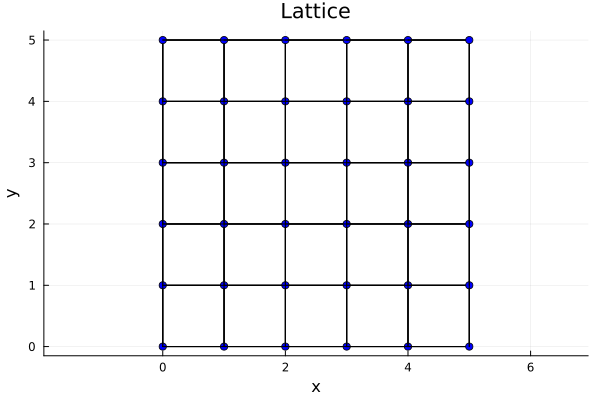

In [3]:
# Plotting the square lattice

function plot_lattice(lattice::Lattice)
    p = plot()
    for i in 1:lattice.num_sites
        site = lattice.sites[i]
        neighs = lattice.neighbors[i]
        for neigh in neighs
            neigh_site = lattice.sites[neigh]
            plot!(p, [site.position[1], neigh_site.position[1]], [site.position[2], neigh_site.position[2]], label="", color=:black)
        end
        if site.spin[3] == 0
            scatter!(p, [site.position[1]], [site.position[2]], label="",color=:blue)
        elseif site.spin[3] == 1
            scatter!(p, [site.position[1]], [site.position[2]], label="",color=:red)
        end

    end
    plot!(p, title="Lattice", xlabel="x", ylabel="y", aspect_ratio=1)
return p
end
p = plot_lattice(square_lattice)
display(p)  

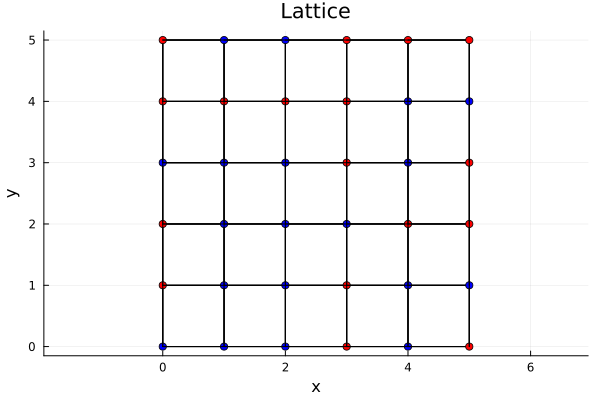

In [4]:
for i in 1:square_lattice.num_sites
    site = square_lattice.sites[i]
    random_spin = rand(Bool) # Randomly assign spin up (true) or down (false)
    site.spin = [0, 0, random_spin] # Update the spin of the site
end
p = plot_lattice(square_lattice)
display(p)

# HoneyComb Lattice

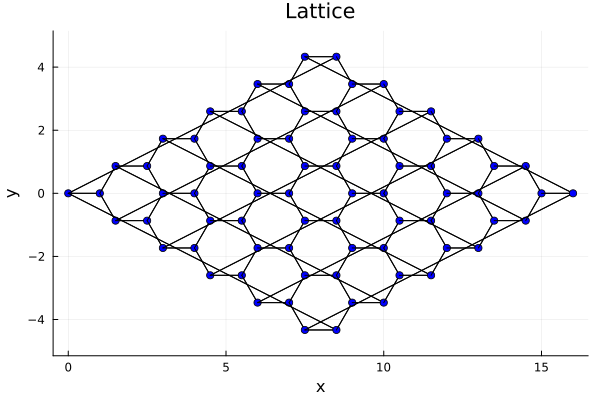

In [5]:
A = [3/2 3/2;
     sqrt(3)/2 -sqrt(3)/2] # Lattice vectors for a triangular lattice

B = [0.0 1.0;
     0.0 0.0]
     
uc_honeycomb = UnitCell(A,B)
rules_honeycomb = [BondRule(1,2,[0,0]),BondRule(1,2,[-1,0]),BondRule(1,2,[0,-1])]
honeycomb_lattice = build_lattice(uc_honeycomb, rules_honeycomb, L)
p = plot_lattice(honeycomb_lattice)
display(p)

# Triangular Lattice

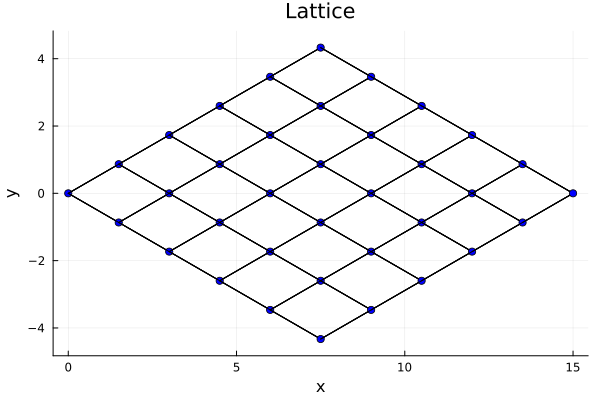

In [6]:
A = [3/2 3/2;
     sqrt(3)/2 -sqrt(3)/2] # Lattice vectors for a triangular lattice

B = [0.0 ;
     0.0 ]
B = reshape(B, (2,1))
uc_triangular = UnitCell(A,B)

rules_triangular = [BondRule(1,1,[0,0]),BondRule(1,1,[-1,0]),BondRule(1,1,[0,-1])]
triangular_lattice = build_lattice(uc_triangular, rules_triangular, L)
p = plot_lattice(triangular_lattice)
display(p)